# Homework Solutions: Lecture 9 - Hypothesis Testing, p-Values & Power

This notebook contains the Python code for the coding exercises (Problems 04, 05).
See the PDF for full analytical solutions to all problems.

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Armenian flag colors for plots
RED = '#D90012'
BLUE = '#0033A0'
ORANGE = '#F2A800'

---
## Problem 04: The p-Hacking Experiment

Simulate the multiple-testing disaster in Python:

- a) Generate 20 independent datasets, each containing two groups of $n = 30$ drawn from **the same** $N(0, 1)$ (so $H_0$ is true for all 20). Run a two-sample $t$-test on each pair. How many give $p < 0.05$?
- b) Repeat the entire experiment 1,000 times. In what fraction of repetitions do you find **at least one** significant result ($p < 0.05$)?
- c) Compare with the theoretical answer: $1 - (1 - 0.05)^{20} \approx\;$?
- d) Take one of the runs where several tests are "significant." Apply **Bonferroni** and **Benjamini-Hochberg** corrections. How many remain significant after each?

In [ ]:
# (a) One round of 20 tests where H0 is true for all
np.random.seed(509)
n_tests = 20
n_per_group = 30

pvals = []
for i in range(n_tests):
    g1 = np.random.normal(0, 1, n_per_group)
    g2 = np.random.normal(0, 1, n_per_group)
    _, p = stats.ttest_ind(g1, g2)
    pvals.append(p)

pvals = np.array(pvals)
sig = np.sum(pvals < 0.05)
print(f'Significant results: {sig} / {n_tests}')
print(f'Expected under H0: {n_tests * 0.05:.1f}')
print()
for i, p in enumerate(pvals):
    marker = ' <-- significant!' if p < 0.05 else ''
    print(f'  Test {i+1:2d}: p = {p:.4f}{marker}')

Significant results: 1 / 20
Expected under H0: 1.0

  Test  1: p = 0.7045
  Test  2: p = 0.3758
  Test  3: p = 0.0443 <-- significant!
  Test  4: p = 0.6994
  Test  5: p = 0.5950
  Test  6: p = 0.2605
  Test  7: p = 0.2512
  Test  8: p = 0.2830
  Test  9: p = 0.7532
  Test 10: p = 0.7017
  Test 11: p = 0.3991
  Test 12: p = 0.3900
  Test 13: p = 0.3180
  Test 14: p = 0.8711
  Test 15: p = 0.2618
  Test 16: p = 0.7285
  Test 17: p = 0.6701
  Test 18: p = 0.6655
  Test 19: p = 0.3118
  Test 20: p = 0.5069


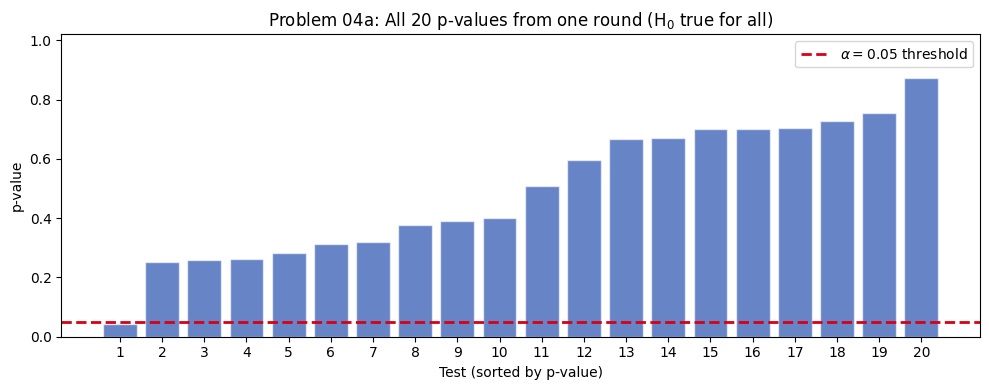

Under H0, p-values are Uniform(0, 1) -- they scatter across [0, 1].
Any that fall below the red line (alpha = 0.05) are false positives.
Here: 1 out of 20 fell below. Expected: 1.


In [7]:
# Visualize: p-values under H0 should be UNIFORM on [0, 1]
# This is the key insight from Problem 03(c) -- let's see it directly.
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(range(1, n_tests + 1), sorted(pvals), color=BLUE, alpha=0.6,
       edgecolor='white')
ax.axhline(0.05, color=RED, linestyle='--', linewidth=2,
           label='$\\alpha = 0.05$ threshold')

# If p-values are truly uniform, we expect them spread evenly across [0, 1]
ax.set_xlabel('Test (sorted by p-value)')
ax.set_ylabel('p-value')
ax.set_title('Problem 04a: All 20 p-values from one round (H$_0$ true for all)')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.02)
ax.set_xticks(range(1, n_tests + 1))
plt.tight_layout()
plt.show()

print(f'Under H0, p-values are Uniform(0, 1) -- they scatter across [0, 1].')
print(f'Any that fall below the red line (alpha = 0.05) are false positives.')
print(f'Here: {sig} out of {n_tests} fell below. Expected: {n_tests * 0.05:.0f}.')

In [8]:
# (b) Repeat the entire experiment 1,000 times
np.random.seed(509)
n_reps = 1000
any_sig_count = 0
n_sig_per_rep = []  # track how many significant per repetition

for rep in range(n_reps):
    ps = []
    for _ in range(n_tests):
        g1 = np.random.normal(0, 1, n_per_group)
        g2 = np.random.normal(0, 1, n_per_group)
        _, p = stats.ttest_ind(g1, g2)
        ps.append(p)
    n_sig = sum(p < 0.05 for p in ps)
    n_sig_per_rep.append(n_sig)
    if n_sig > 0:
        any_sig_count += 1

print(f'Fraction with at least one significant: {any_sig_count/n_reps:.4f}')
print(f'Mean number of significant per round:   {np.mean(n_sig_per_rep):.2f}')

Fraction with at least one significant: 0.6220
Mean number of significant per round:   0.97


In [9]:
# (c) Theoretical answer
theoretical = 1 - 0.95**20
print(f'Theoretical P(at least one sig) = 1 - 0.95^20 = {theoretical:.4f}')
print(f'Simulated                                     = {any_sig_count/n_reps:.4f}')
print(f'\nThey match closely!')

Theoretical P(at least one sig) = 1 - 0.95^20 = 0.6415
Simulated                                     = 0.6220

They match closely!


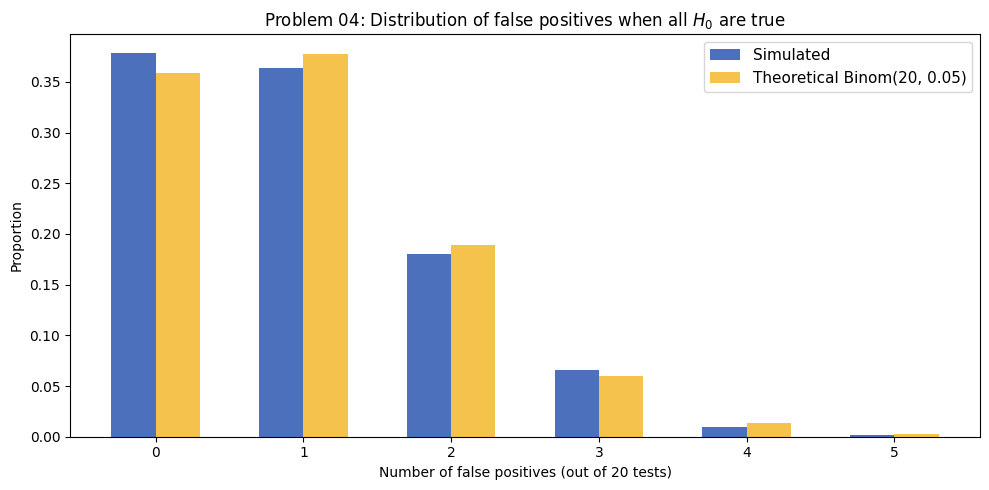

P(0 false positives) = 0.378  (theoretical: 0.358)
P(>=1 false positive) = 0.622  (theoretical: 0.642)


In [10]:
# Histogram: how many false positives per round?
fig, ax = plt.subplots(figsize=(10, 5))

counts = np.bincount(n_sig_per_rep, minlength=6)
x_vals = np.arange(len(counts))

# Theoretical: Binomial(20, 0.05)
from scipy.stats import binom
binom_probs = binom.pmf(x_vals, n_tests, 0.05)

ax.bar(x_vals - 0.15, counts / n_reps, width=0.3, color=BLUE, alpha=0.7,
       label='Simulated')
ax.bar(x_vals + 0.15, binom_probs, width=0.3, color=ORANGE, alpha=0.7,
       label='Theoretical Binom(20, 0.05)')

ax.set_xlabel('Number of false positives (out of 20 tests)')
ax.set_ylabel('Proportion')
ax.set_title('Problem 04: Distribution of false positives when all $H_0$ are true')
ax.set_xticks(x_vals)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'P(0 false positives) = {counts[0]/n_reps:.3f}  (theoretical: {binom_probs[0]:.3f})')
print(f'P(>=1 false positive) = {1 - counts[0]/n_reps:.3f}  (theoretical: {1-binom_probs[0]:.3f})')

### Part (d): Multiple testing corrections

To demonstrate the corrections, we need a run with several "significant" results.
We deliberately search for one below - notice this is **exactly what p-hacking looks like**:
keep running experiments until something "works." The whole point of part (d)
is to show that corrections can catch this.

In [ ]:
# Deliberately search for a run with >= 3 "significant" results.
# This IS p-hacking - we're doing it on purpose to have interesting
# p-values to correct. In real life, this is exactly what you must NOT do.
np.random.seed(42)
for attempt in range(200):
    ps = []
    for _ in range(n_tests):
        g1 = np.random.normal(0, 1, n_per_group)
        g2 = np.random.normal(0, 1, n_per_group)
        _, p = stats.ttest_ind(g1, g2)
        ps.append(p)
    if sum(p < 0.05 for p in ps) >= 3:
        break

ps = np.array(ps)
print(f'Found a run with {np.sum(ps < 0.05)} significant results (after {attempt+1} attempts)')
print(f'We had to try {attempt+1} times - that alone should be suspicious!')

In [ ]:
# --- Bonferroni correction (by hand) ---
# Idea: multiply each p-value by the number of tests.
# Reject if adjusted p < alpha.
alpha = 0.05
m = len(ps)  # number of tests

bonf_adjusted = np.minimum(ps * m, 1.0)  # cap at 1
bonf_reject = bonf_adjusted < alpha

print('=== Bonferroni (by hand) ===')
print(f'Threshold per test: {alpha} / {m} = {alpha/m}')
print(f'Equivalently: multiply each p by {m}, reject if < {alpha}')
print()
for i in range(m):
    if ps[i] < alpha:
        status = 'REJECT' if bonf_reject[i] else 'fail to reject'
        print(f'  Test {i+1:2d}: p = {ps[i]:.4f}  ->  adjusted = {bonf_adjusted[i]:.4f}  ->  {status}')
print(f'\nSurvivors: {np.sum(bonf_reject)}')

In [ ]:
# --- Benjamini-Hochberg correction (by hand) ---
# Step 1: sort p-values
# Step 2: for rank k, compute threshold = (k / m) * alpha
# Step 3: find the largest k where p_(k) <= threshold
# Step 4: reject all tests with rank <= that k

sorted_indices = np.argsort(ps)
sorted_ps = ps[sorted_indices]
ranks = np.arange(1, m + 1)
bh_thresholds = (ranks / m) * alpha

print('=== Benjamini-Hochberg (by hand) ===')
print(f'{"Rank":>4}  {"Test":>4}  {"p-value":>8}  {"BH threshold":>13}  {"p <= thresh?":>12}')
print('-' * 55)

# Find the largest rank where p_(k) <= threshold
bh_pass = sorted_ps <= bh_thresholds
if np.any(bh_pass):
    max_k = np.max(np.where(bh_pass)[0])  # largest rank (0-indexed) that passes
else:
    max_k = -1  # nothing passes

for k in range(m):
    passes = 'yes' if sorted_ps[k] <= bh_thresholds[k] else 'no'
    marker = '  <-- cutoff' if k == max_k else ''
    print(f'{k+1:4d}  {sorted_indices[k]+1:4d}  {sorted_ps[k]:8.4f}  {bh_thresholds[k]:13.4f}  {passes:>12}{marker}')
    if k >= 5 and k < m - 1:  # truncate middle for readability
        if k == 6:
            print(f'  ... (remaining {m - 7} rows omitted, all p >> threshold) ...')
            break

# Reject all with rank <= max_k
bh_reject = np.zeros(m, dtype=bool)
if max_k >= 0:
    bh_reject[sorted_indices[:max_k + 1]] = True

print(f'\nLargest k where p_(k) <= threshold: {max_k + 1 if max_k >= 0 else "none"}')
print(f'Reject all tests with rank <= {max_k + 1}: {np.sum(bh_reject)} test(s)')

In [ ]:
# Verify our manual implementation matches statsmodels
from statsmodels.stats.multitest import multipletests

reject_bonf_lib, _, _, _ = multipletests(ps, alpha=0.05, method='bonferroni')
reject_bh_lib, _, _, _ = multipletests(ps, alpha=0.05, method='fdr_bh')

print('=== Verification against statsmodels ===')
print(f'Bonferroni - manual: {np.sum(bonf_reject)}, statsmodels: {np.sum(reject_bonf_lib)}, match: {np.all(bonf_reject == reject_bonf_lib)}')
print(f'BH         - manual: {np.sum(bh_reject)}, statsmodels: {np.sum(reject_bh_lib)}, match: {np.all(bh_reject == reject_bh_lib)}')

In [ ]:
# Summary: which originally-significant tests survived?
print(f'Before correction: {np.sum(ps < 0.05)} significant')
print(f'After Bonferroni:  {np.sum(bonf_reject)} significant')
print(f'After BH (FDR):    {np.sum(bh_reject)} significant')
print()
for i in range(m):
    if ps[i] < 0.05:
        bonf_status = 'survives' if bonf_reject[i] else 'killed'
        bh_status = 'survives' if bh_reject[i] else 'killed'
        print(f'  Test {i+1:2d}: p = {ps[i]:.4f}  |  '
              f'Bonferroni: {bonf_status}  |  BH: {bh_status}')

In [ ]:
# Visual: p-values with correction thresholds
fig, ax = plt.subplots(figsize=(10, 5))

sorted_ps_plot = np.sort(ps)
ranks_plot = np.arange(1, n_tests + 1)

ax.scatter(ranks_plot, sorted_ps_plot, color=BLUE, s=80, zorder=5,
           label='Sorted p-values')

# Bonferroni threshold (flat line)
ax.axhline(0.05 / n_tests, color=RED, linestyle='--', linewidth=2,
           label=f'Bonferroni threshold = {0.05/n_tests:.4f}')

# BH thresholds (diagonal line)
bh_thresholds_plot = ranks_plot / n_tests * 0.05
ax.plot(ranks_plot, bh_thresholds_plot, color=ORANGE, linestyle='-',
        linewidth=2, label='BH thresholds (k/m * 0.05)')

# Original threshold
ax.axhline(0.05, color='gray', linestyle=':', linewidth=1.5,
           label='Uncorrected threshold = 0.05')

ax.set_xlabel('Rank')
ax.set_ylabel('p-value')
ax.set_title('Problem 04d: Sorted p-values with Bonferroni and BH thresholds')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print('Points below a line are rejected by that method.')
print('BH (orange diagonal) is always more lenient than Bonferroni (red flat line).')
print('Both are stricter than the uncorrected threshold (gray dotted).')

---
## Problem 05: Build Your Own Permutation Test

Treatment group: $[5.2,\; 6.1,\; 7.3,\; 5.8,\; 6.9]$; Control group: $[4.1,\; 3.9,\; 5.0,\; 4.5,\; 4.3]$.

- a) Compute the observed difference in means $\bar{X}_T - \bar{X}_C$.
- b) Under $H_0$ (no treatment effect), all $\binom{10}{5} = 252$ ways to split the 10 values into two groups of 5 are equally likely. Enumerate all 252 permutations and compute $\bar{X}_T^* - \bar{X}_C^*$ for each.
- c) What fraction of permutations produce a difference $\geq$ the observed value? This is your **exact** one-sided p-value.
- d) Compare with the Welch $t$-test p-value (`scipy.stats.ttest_ind`). Do they agree?

In [ ]:
from itertools import combinations

treatment = np.array([5.2, 6.1, 7.3, 5.8, 6.9])
control = np.array([4.1, 3.9, 5.0, 4.5, 4.3])

# (a) Observed difference
obs_diff = treatment.mean() - control.mean()
print(f'Treatment mean = {treatment.mean():.2f}')
print(f'Control mean   = {control.mean():.2f}')
print(f'Observed difference = {obs_diff:.2f}')

In [ ]:
# (b) Enumerate all 252 permutations
pooled = np.concatenate([treatment, control])
n_total = len(pooled)
n_treat = len(treatment)

perm_diffs = []
for idx in combinations(range(n_total), n_treat):
    grp1 = pooled[list(idx)]
    mask = [i for i in range(n_total) if i not in idx]
    grp2 = pooled[mask]
    perm_diffs.append(grp1.mean() - grp2.mean())

perm_diffs = np.array(perm_diffs)
print(f'Number of permutations: {len(perm_diffs)}')
print(f'Min difference: {perm_diffs.min():.2f}')
print(f'Max difference: {perm_diffs.max():.2f}')
print(f'Mean difference: {perm_diffs.mean():.4f}  (should be ~0 by symmetry)')

In [ ]:
# Show the most extreme permutations to build intuition
sorted_diffs = np.sort(perm_diffs)[::-1]  # descending

print('Top 5 most extreme permutation differences (treatment favored):')
print(f'  Rank 1: {sorted_diffs[0]:+.2f}  <-- this is our observed split (the 5 largest values)')
print(f'  Rank 2: {sorted_diffs[1]:+.2f}')
print(f'  Rank 3: {sorted_diffs[2]:+.2f}')
print(f'  Rank 4: {sorted_diffs[3]:+.2f}')
print(f'  Rank 5: {sorted_diffs[4]:+.2f}')
print()
print('Bottom 5 (control favored):')
for i in range(5):
    print(f'  Rank {252-4+i}: {sorted_diffs[-(5-i)]:+.2f}')
print()
print(f'The distribution is symmetric: max = {sorted_diffs[0]:+.2f}, min = {sorted_diffs[-1]:+.2f}')
print(f'Gap between rank 1 and rank 2: {sorted_diffs[0] - sorted_diffs[1]:.2f}')
print(f'  -> our observed difference is isolated at the extreme.')

In [ ]:
# (c) Exact one-sided p-value
n_extreme = np.sum(perm_diffs >= obs_diff)
p_perm = n_extreme / len(perm_diffs)
print(f'Permutations with diff >= {obs_diff:.2f}: {n_extreme} / {len(perm_diffs)}')
print(f'Exact one-sided p-value = {p_perm:.5f}')
print()
print(f'The observed split is the MOST extreme possible --')
print(f'the treatment group contains the 5 largest values in the dataset.')
print()
print(f'Sorted pooled data: {np.sort(pooled)}')
print(f'Treatment group:    {np.sort(treatment)}')
print(f'  -> these ARE the top 5 values.')
print()
# Common mistake: computing a two-sided p-value
n_two_sided = np.sum(np.abs(perm_diffs) >= obs_diff)
print(f'NOTE: if you computed a TWO-sided p-value (|diff| >= {obs_diff:.2f}),')
print(f'you would get {n_two_sided}/{len(perm_diffs)} = {n_two_sided/len(perm_diffs):.5f}.')
print(f'The problem asks for one-sided (diff >= observed), so the answer is {n_extreme}/{len(perm_diffs)}.')

In [ ]:
# (d) Welch t-test for comparison
t_stat, p_welch = stats.ttest_ind(treatment, control, equal_var=False)
print(f'Welch t-statistic = {t_stat:.3f}')
print(f'Welch two-sided p = {p_welch:.4f}')
print(f'Welch one-sided p = {p_welch/2:.4f}')
print()
print(f'Permutation p-value (one-sided) = {p_perm:.4f}')
print(f'Welch one-sided p               = {p_welch/2:.4f}')
print()
print('Both are highly significant (p < 0.005). The permutation test gives')
print('a slightly larger p-value (more conservative). This is because:')
print('  - The t-test assumes normal data and uses a continuous distribution')
print('  - The permutation test makes NO distributional assumptions and uses')
print('    the exact discrete null distribution (only 252 possible values)')
print()
print('With n=5 per group, the permutation test is arguably more trustworthy')
print('since we cannot verify normality with so few observations.')

In [ ]:
# Histogram of the permutation null distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(perm_diffs, bins=30, density=True, color=BLUE, alpha=0.4,
        edgecolor='white', label='Permutation null distribution')

# Mark the observed difference
ax.axvline(obs_diff, color=RED, linestyle='--', linewidth=2.5,
           label=f'Observed diff = {obs_diff:.2f}')

# Shade the rejection region
extreme_diffs = perm_diffs[perm_diffs >= obs_diff]
if len(extreme_diffs) > 0:
    ax.axvspan(obs_diff - 0.02, perm_diffs.max() + 0.1,
               alpha=0.15, color=RED,
               label=f'p-value region ({n_extreme}/{len(perm_diffs)})')

ax.set_xlabel('Difference in means ($\\bar{X}_T^* - \\bar{X}_C^*$)')
ax.set_ylabel('Density')
ax.set_title('Problem 05: Exact permutation null distribution (all 252 permutations)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nThe observed difference of {obs_diff:.2f} is at the extreme right tail.')
print(f'Only {n_extreme} out of {len(perm_diffs)} permutations are this extreme or more.')